# Floral Anomaly Detector
Using dataset compiled by using Wikipedia & Wikidata API.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
import pickle

In [2]:
data = pd.read_csv("flora_dataset.csv")
data.head(10)

,common_name,scientific_name,country,habitat
0,NaN,Aa argyrolepis,Bolivia,NaN
1,NaN,Aa argyrolepis,Colombia,NaN
2,NaN,Aa argyrolepis,Peru,NaN
3,NaN,Aa aurantiaca,Peru,NaN
4,NaN,Aa calceata,Bolivia,NaN
5,NaN,Aa calceata,Peru,NaN
6,NaN,Aa colombiana,Colombia,NaN
7,NaN,Aa erosa,Peru,NaN
8,NaN,Aa lorentzii,Argentina,NaN
9,NaN,Aa lozanoi,Colombia,NaN


In [3]:
# Extract genus from the scientific name. This lets us ask questions like 'is this genus ever found in this country?' independent of the exact species.
data['genus'] = data['scientific_name'].str.split().str[0]

# Pre-compute lookup tables used both during training and at inference time.
genus_country_freq = (
    data.groupby(['genus', 'country'])
    .size().reset_index(name='genus_country_freq')
)
species_country_freq = (
    data.groupby(['scientific_name', 'country'])
    .size().reset_index(name='species_country_freq')
)
species_total_countries = (
    data.groupby('scientific_name')['country']
    .nunique().reset_index(name='species_total_countries')
)
genus_total_countries = (
    data.groupby('genus')['country']
    .nunique().reset_index(name='genus_total_countries')
)

data = data.merge(genus_country_freq, on=['genus', 'country'], how='left')
data = data.merge(species_country_freq, on=['scientific_name', 'country'], how='left')
data = data.merge(species_total_countries, on='scientific_name', how='left')
data = data.merge(genus_total_countries, on='genus', how='left')

print(f"Rows after merging frequency tables: {len(data)}")
data[['scientific_name', 'country', 'habitat', 'genus_country_freq', 'species_total_countries']].head()

Rows after merging frequency tables: 72458


,scientific_name,country,habitat,genus_country_freq,species_total_countries
0,Aa argyrolepis,Bolivia,NaN,6,3
1,Aa argyrolepis,Colombia,NaN,3,3
2,Aa argyrolepis,Peru,NaN,6,3
3,Aa aurantiaca,Peru,NaN,6,1
4,Aa calceata,Bolivia,NaN,6,2


In [4]:
# Only rows with a habitat value are used for the full model.
df_model = data[data['habitat'].notna()].copy()
df_model['primary_habitat'] = df_model['habitat'].str.split(';').str[0].str.strip()

# Habitat-level lookup tables.
hab_country_freq = (
    df_model.groupby(['primary_habitat', 'country'])
    .size().reset_index(name='hab_country_freq')
)
genus_habitat_freq = (
    df_model.groupby(['genus', 'primary_habitat'])
    .size().reset_index(name='genus_habitat_freq')
)
species_habitat_freq = (
    df_model.groupby(['scientific_name', 'primary_habitat'])
    .size().reset_index(name='species_habitat_freq')
)
country_total = (
    df_model.groupby('country')
    .size().reset_index(name='country_total_entries')
)
habitat_total = (
    df_model.groupby('primary_habitat')
    .size().reset_index(name='habitat_total_entries')
)
country_habitat_diversity = (
    df_model.groupby('country')['primary_habitat']
    .nunique().reset_index(name='country_habitat_diversity')
)

df_model = df_model.merge(hab_country_freq, on=['primary_habitat', 'country'], how='left')
df_model = df_model.merge(genus_habitat_freq, on=['genus', 'primary_habitat'], how='left')
df_model = df_model.merge(species_habitat_freq, on=['scientific_name', 'primary_habitat'], how='left')
df_model = df_model.merge(country_total, on='country', how='left')
df_model = df_model.merge(habitat_total, on='primary_habitat', how='left')
df_model = df_model.merge(country_habitat_diversity, on='country', how='left')

# Fraction of a country's known flora entries that belong to this habitat.
# A desert plant in Norway gets 0.0 here because Norway has zero desert entries.
# This is the most direct signal for geographic plausibility.
df_model['hab_frac_in_country'] = (
    df_model['hab_country_freq'].fillna(0) / df_model['country_total_entries']
)

# Fraction of all entries in this habitat type that belong to this genus.
# A cactus genus in a tundra habitat would score very low here.
df_model['genus_frac_in_habitat'] = (
    df_model['genus_habitat_freq'].fillna(0) / df_model['habitat_total_entries']
)

# Log-scale the raw counts so high-frequency entries don't dominate.
count_cols = [
    'genus_country_freq', 'species_country_freq', 'hab_country_freq',
    'genus_habitat_freq', 'species_habitat_freq', 'country_total_entries',
]
for col in count_cols:
    df_model[col] = df_model[col].fillna(0)
    df_model[f'log_{col}'] = np.log1p(df_model[col])

# Minimum support filter: habitats with very few entries dataset-wide cannot be reliably scored. The model has no basis for what 'normal' looks like in that habitat, so every entry in it appears suspicious.
# These are flagged as 'insufficient data' rather than scored as anomalies.
MIN_HABITAT_SUPPORT = 30
low_support_habitats = habitat_total[
    habitat_total['habitat_total_entries'] < MIN_HABITAT_SUPPORT
]['primary_habitat'].tolist()

df_low_support = df_model[df_model['primary_habitat'].isin(low_support_habitats)].copy()
df_model = df_model[~df_model['primary_habitat'].isin(low_support_habitats)].copy()

print(f"Excluded habitats (insufficient data): {low_support_habitats}")
print(f"Excluded rows: {len(df_low_support)} | Remaining: {len(df_model)}")

le_country = LabelEncoder()
le_habitat = LabelEncoder()
df_model['country_enc'] = le_country.fit_transform(df_model['country'])
df_model['habitat_enc'] = le_habitat.fit_transform(df_model['primary_habitat'])

print(f"Model rows: {len(df_model)} | countries: {df_model['country'].nunique()} | habitats: {df_model['primary_habitat'].nunique()}")
df_model[['scientific_name', 'country', 'primary_habitat', 'hab_frac_in_country', 'genus_frac_in_habitat']].head()

Excluded habitats (insufficient data): ['tundra']
Excluded rows: 6 | Remaining: 22333
Model rows: 22333 | countries: 199 | habitats: 7


,scientific_name,country,primary_habitat,hab_frac_in_country,genus_frac_in_habitat
0,Aa mandonii,Bolivia,grasslands,0.122549,0.001099
1,Aa matthewsii,Bolivia,grasslands,0.122549,0.001099
2,Aa matthewsii,Peru,grasslands,0.042857,0.001099
3,Abarema cochliacarpos,Brazil,grasslands,0.112903,0.000366
4,Abies cephalonica,Greece,mountains,0.452381,0.006624


In [5]:
FEATURE_COLS = [
    'log_genus_country_freq',
    'log_species_country_freq',
    'log_hab_country_freq',
    'log_genus_habitat_freq',
    'log_species_habitat_freq',
    'log_country_total_entries',
    'hab_frac_in_country',
    'genus_frac_in_habitat',
    'country_habitat_diversity',
    'species_total_countries',
    'genus_total_countries',
    'country_enc',
    'habitat_enc',
]

X = df_model[FEATURE_COLS]

# IsolationForest captures within-distribution statistical weirdness: entries that are statistically unusual compared to similar records.
iforest = IsolationForest(n_estimators=300, contamination=0.05, random_state=42, n_jobs=-1)
iforest.fit(X)

df_model['if_score'] = iforest.decision_function(X)

# Normalise IsolationForest score to 0-1 range.
IF_MIN = df_model['if_score'].min()
IF_MAX = df_model['if_score'].max()
df_model['if_norm'] = (df_model['if_score'] - IF_MIN) / (IF_MAX - IF_MIN)

# Plausibility score: directly encodes geographic and habitat fitness.
# IsolationForest alone cannot flag unseen combos (like Norway+desert) because it only learned from entries that already exist in the dataset.
# This score catches those zero-frequency cases directly.
def compute_plausibility(hab_frac, genus_hab_frac, genus_country_seen):
    hab_score      = np.clip(hab_frac * 10, 0, 1)           # 0 if habitat never seen in country
    genus_hab_score = np.clip(genus_hab_frac * 5, 0, 1)     # 0 if genus never in this habitat
    gc_bonus       = 0.1 * genus_country_seen               # small boost if genus is known in country
    return np.clip((hab_score * 0.5 + genus_hab_score * 0.4 + gc_bonus) / 1.1, 0, 1)

df_model['plaus_score'] = compute_plausibility(
    df_model['hab_frac_in_country'],
    df_model['genus_frac_in_habitat'],
    (df_model['genus_country_freq'] > 0).astype(float),
)

# Final score: weighted combination of both signals.
# Plausibility weighted higher (0.6) because it directly captures the geographic signal.
df_model['final_score'] = 0.4 * df_model['if_norm'] + 0.6 * df_model['plaus_score']

# Flag the bottom 5 percent as anomalies.
THRESHOLD = df_model['final_score'].quantile(0.05)
df_model['is_anomaly'] = (df_model['final_score'] < THRESHOLD).astype(int)

n_anomalies = df_model['is_anomaly'].sum()
print(f"Decision threshold: {THRESHOLD:.4f}")
print(f"Total entries: {len(df_model)} | Flagged anomalies: {n_anomalies}")

Decision threshold: 0.4788
Total entries: 22333 | Flagged anomalies: 1117


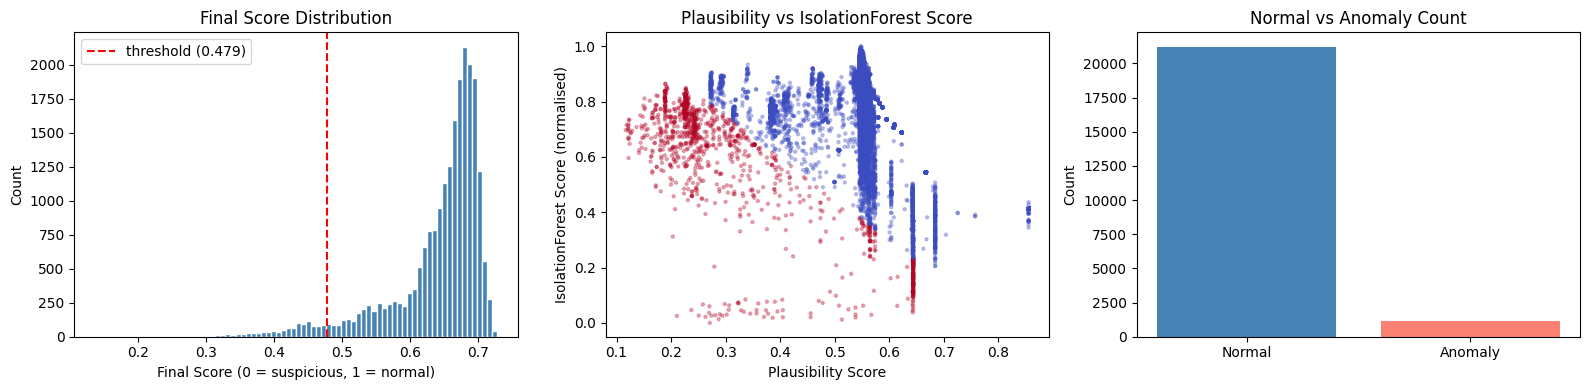

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_model['final_score'], bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(THRESHOLD, color='red', linestyle='--', label=f'threshold ({THRESHOLD:.3f})')
axes[0].set_title('Final Score Distribution')
axes[0].set_xlabel('Final Score (0 = suspicious, 1 = normal)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].scatter(
    df_model['plaus_score'], df_model['if_norm'],
    c=df_model['is_anomaly'], cmap='coolwarm', alpha=0.3, s=5,
)
axes[1].set_title('Plausibility vs IsolationForest Score')
axes[1].set_xlabel('Plausibility Score')
axes[1].set_ylabel('IsolationForest Score (normalised)')

counts = df_model['is_anomaly'].value_counts().rename({0: 'Normal', 1: 'Anomaly'})
axes[2].bar(counts.index, counts.values, color=['steelblue', 'salmon'])
axes[2].set_title('Normal vs Anomaly Count')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [7]:
top_anomalies = (
    df_model[df_model['is_anomaly'] == 1]
    [['scientific_name', 'common_name', 'country', 'primary_habitat',
      'hab_frac_in_country', 'genus_frac_in_habitat',
      'genus_country_freq', 'plaus_score', 'final_score']]
    .sort_values('final_score')
    .head(30)
    .reset_index(drop=True)
)

top_anomalies

,scientific_name,common_name,country,primary_habitat,hab_frac_in_country,genus_frac_in_habitat,genus_country_freq,plaus_score,final_score
0,Cyperus cuspidatus,coastal plain flatsedge,Bolivia,coastal,0.004902,0.053543,50,0.210542,0.136404
1,Cyperus cuspidatus,coastal plain flatsedge,Peru,coastal,0.010714,0.053543,37,0.236962,0.160651
2,Cyperus cuspidatus,coastal plain flatsedge,Nigeria,coastal,0.013699,0.053543,40,0.250527,0.160883
3,Cyperus cuspidatus,coastal plain flatsedge,Uganda,coastal,0.018182,0.053543,56,0.270905,0.162543
4,Cyperus cuspidatus,coastal plain flatsedge,Angola,coastal,0.016393,0.053543,54,0.262776,0.166392
5,Cyperus cuspidatus,coastal plain flatsedge,Ivory Coast,coastal,0.018868,0.053543,37,0.274024,0.174772
6,Cyperus cuspidatus,coastal plain flatsedge,Guyana,coastal,0.017857,0.053543,24,0.269429,0.176101
7,Cyperus cuspidatus,coastal plain flatsedge,Sudan,coastal,0.021739,0.053543,47,0.287075,0.177603
8,Cyperus cuspidatus,coastal plain flatsedge,Gabon,coastal,0.020408,0.053543,28,0.281025,0.179653
9,Cyperus cuspidatus,coastal plain flatsedge,Malaysia,coastal,0.015385,0.053543,14,0.258191,0.181469


C:\Users\mats\AppData\Local\Temp\ipykernel_35596\1441742444.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hab_anomaly_rate, x='anomaly_rate', y='habitat', palette='flare')


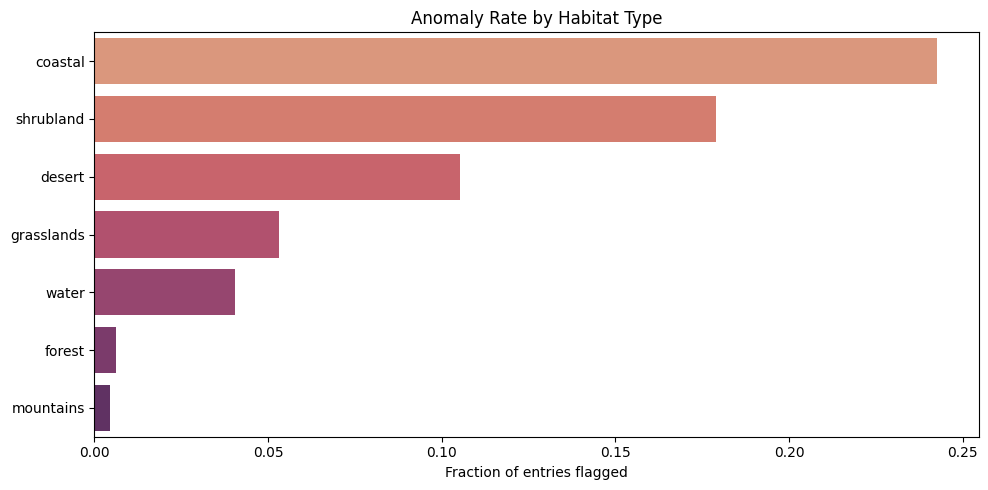

In [8]:
hab_anomaly_rate = (
    df_model.groupby('primary_habitat')['is_anomaly']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
hab_anomaly_rate.columns = ['habitat', 'anomaly_rate']

plt.figure(figsize=(10, 5))
sns.barplot(data=hab_anomaly_rate, x='anomaly_rate', y='habitat', palette='flare')
plt.title('Anomaly Rate by Habitat Type')
plt.xlabel('Fraction of entries flagged')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [9]:
def check_entry(scientific_name: str, country: str, habitat: str) -> dict:
    """
    Score a single plant/country/habitat combination.
    Returns a verdict with score breakdown for interpretability.
    """
    genus = scientific_name.split()[0]
    primary_habitat = habitat.split(';')[0].strip()

    gc_v  = genus_country_freq.query('genus==@genus and country==@country')['genus_country_freq']
    sc_v  = species_country_freq.query('scientific_name==@scientific_name and country==@country')['species_country_freq']
    stc_v = species_total_countries.query('scientific_name==@scientific_name')['species_total_countries']
    gtc_v = genus_total_countries.query('genus==@genus')['genus_total_countries']
    hc_v  = hab_country_freq.query('primary_habitat==@primary_habitat and country==@country')['hab_country_freq']
    gh_v  = genus_habitat_freq.query('genus==@genus and primary_habitat==@primary_habitat')['genus_habitat_freq']
    sh_v  = species_habitat_freq.query('scientific_name==@scientific_name and primary_habitat==@primary_habitat')['species_habitat_freq']
    ct_v  = country_total.query('country==@country')['country_total_entries']
    ht_v  = habitat_total.query('primary_habitat==@primary_habitat')['habitat_total_entries']
    cd_v  = country_habitat_diversity.query('country==@country')['country_habitat_diversity']

    gc  = float(gc_v.values[0])  if len(gc_v)  else 0.0
    sc  = float(sc_v.values[0])  if len(sc_v)  else 0.0
    stc = float(stc_v.values[0]) if len(stc_v) else 1.0
    gtc = float(gtc_v.values[0]) if len(gtc_v) else 1.0
    hc  = float(hc_v.values[0])  if len(hc_v)  else 0.0
    gh  = float(gh_v.values[0])  if len(gh_v)  else 0.0
    sh  = float(sh_v.values[0])  if len(sh_v)  else 0.0
    ct  = float(ct_v.values[0])  if len(ct_v)  else 1.0
    ht  = float(ht_v.values[0])  if len(ht_v)  else 1.0
    cd  = float(cd_v.values[0])  if len(cd_v)  else 1.0

    try: c_enc = int(le_country.transform([country])[0])
    except: c_enc = 0
    try: h_enc = int(le_habitat.transform([primary_habitat])[0])
    except: h_enc = 0

    hab_frac   = hc / ct
    genus_frac = gh / ht

    row = pd.DataFrame([{
        'log_genus_country_freq':    np.log1p(gc),
        'log_species_country_freq':  np.log1p(sc),
        'log_hab_country_freq':      np.log1p(hc),
        'log_genus_habitat_freq':    np.log1p(gh),
        'log_species_habitat_freq':  np.log1p(sh),
        'log_country_total_entries': np.log1p(ct),
        'hab_frac_in_country':       hab_frac,
        'genus_frac_in_habitat':     genus_frac,
        'country_habitat_diversity': cd,
        'species_total_countries':   stc,
        'genus_total_countries':     gtc,
        'country_enc':               c_enc,
        'habitat_enc':               h_enc,
    }])

    if_s  = float(iforest.decision_function(row)[0])
    if_n  = (if_s - IF_MIN) / (IF_MAX - IF_MIN)
    plaus = float(compute_plausibility(hab_frac, genus_frac, float(gc > 0)))
    final = 0.4 * if_n + 0.6 * plaus

    if primary_habitat in low_support_habitats:
        verdict = 'INSUFFICIENT DATA: habitat too rare in dataset to score reliably'
    elif final < THRESHOLD:
        verdict = 'ANOMALY: suspicious entry'
    else:
        verdict = 'NORMAL: plausible entry'

    return {
        'scientific_name':   scientific_name,
        'country':           country,
        'habitat':           habitat,
        'final_score':       round(final, 4),
        'plausibility':      round(plaus, 4),
        'if_score':          round(if_s, 4),
        'hab_frac_country':  round(hab_frac, 4),
        'verdict':           verdict,
    }


check_entry('Opuntia humifusa', 'Norway', 'desert')

{'scientific_name': 'Opuntia humifusa',
 'country': 'Norway',
 'habitat': 'desert',
 'final_score': np.float64(0.2307),
 'plausibility': 0.01,
 'if_score': 0.0358,
 'hab_frac_country': 0.0,
 'verdict': 'ANOMALY: suspicious entry'}

C:\Users\mats\AppData\Local\Temp\ipykernel_35596\463796446.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


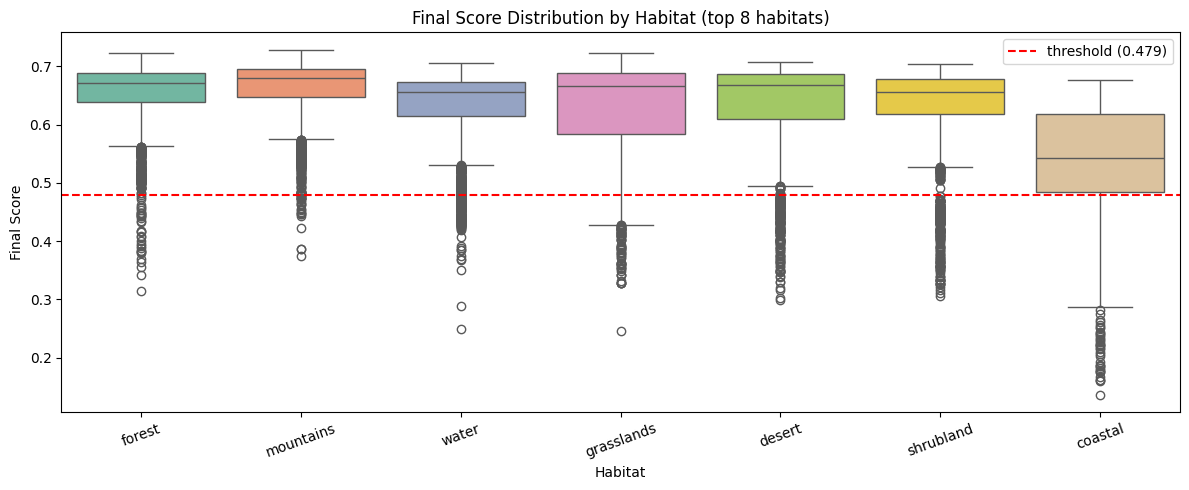

In [10]:
top_habitats = df_model['primary_habitat'].value_counts().head(8).index
plot_data = df_model[df_model['primary_habitat'].isin(top_habitats)]

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=plot_data,
    x='primary_habitat',
    y='final_score',
    palette='Set2',
    order=top_habitats,
)
plt.axhline(THRESHOLD, color='red', linestyle='--', label=f'threshold ({THRESHOLD:.3f})')
plt.title('Final Score Distribution by Habitat (top 8 habitats)')
plt.xlabel('Habitat')
plt.ylabel('Final Score')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

## Testing
Test set was generated by Claude 4.6 based on real flora dataset

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

test_data = pd.read_csv("test_dataset.csv")

results = []
for _, row in test_data.iterrows():
    result = check_entry(row['scientific_name'], row['country'], row['habitat'])
    result['true_label'] = row['label']
    result['suspicious_reason'] = row['suspicious_reason'] if pd.notna(row['suspicious_reason']) else ''
    results.append(result)

results_df = pd.DataFrame(results)

def verdict_to_pred(verdict):
    if 'ANOMALY' in verdict or 'INSUFFICIENT' in verdict:
        return 'fake'
    return 'real'

results_df['predicted_label'] = results_df['verdict'].apply(verdict_to_pred)

correct = (results_df['true_label'] == results_df['predicted_label']).sum()
total = len(results_df)
print(f"Accuracy: {correct}/{total} ({correct/total*100:.1f}%)")
print()
print(classification_report(results_df['true_label'], results_df['predicted_label'], target_names=['fake', 'real']))

Accuracy: 92/100 (92.0%)

              precision    recall  f1-score   support

        fake       0.84      0.90      0.87        30
        real       0.96      0.93      0.94        70

    accuracy                           0.92       100
   macro avg       0.90      0.91      0.91       100
weighted avg       0.92      0.92      0.92       100



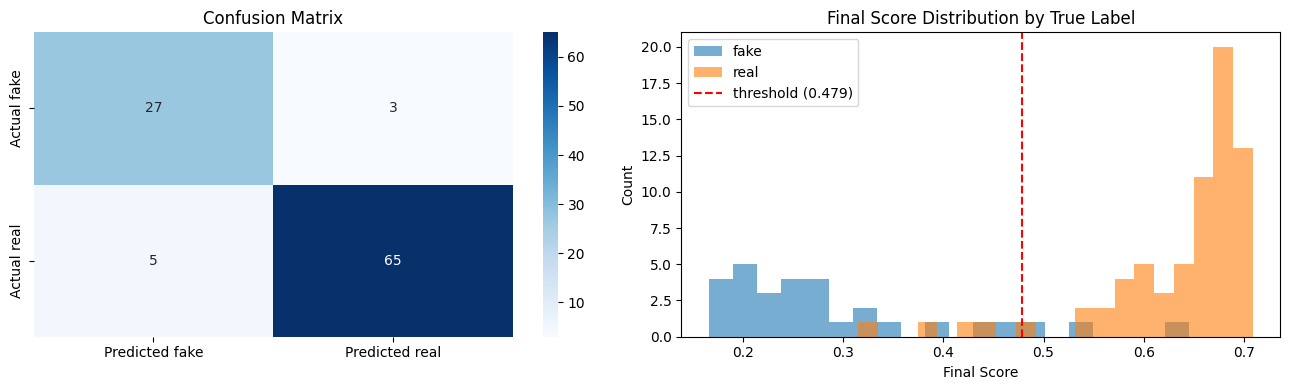

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(results_df['true_label'], results_df['predicted_label'], labels=['fake', 'real'])
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted fake', 'Predicted real'],
    yticklabels=['Actual fake', 'Actual real'],
    ax=axes[0],
)
axes[0].set_title('Confusion Matrix')

scoreable = results_df[~results_df['verdict'].str.startswith('INSUFFICIENT')]
for label, group in scoreable.groupby('true_label'):
    axes[1].hist(group['final_score'], bins=20, alpha=0.6, label=label)
axes[1].axvline(THRESHOLD, color='red', linestyle='--', label=f'threshold ({THRESHOLD:.3f})')
axes[1].set_title('Final Score Distribution by True Label')
axes[1].set_xlabel('Final Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

### How could this model be improved?
- By gathering the missing habitat data from other plants in the dataset to give the model a larger training set.
- Further fine tuning of the model.

In [ ]:
# Bundle everything check_entry depends on into a single dict.
# The lookup tables are included because check_entry queries them
# at inference time, not just at training time.
model_bundle = {
    # The model and its score normalisation bounds.
    'iforest':    iforest,
    'IF_MIN':     IF_MIN,
    'IF_MAX':     IF_MAX,
    'THRESHOLD':  THRESHOLD,

    # Label encoders, needed to transform country/habitat strings to ints.
    'le_country': le_country,
    'le_habitat': le_habitat,

    # Frequency lookup tables.
    'genus_country_freq':       genus_country_freq,
    'species_country_freq':     species_country_freq,
    'species_total_countries':  species_total_countries,
    'genus_total_countries':    genus_total_countries,
    'hab_country_freq':         hab_country_freq,
    'genus_habitat_freq':       genus_habitat_freq,
    'species_habitat_freq':     species_habitat_freq,
    'country_total':            country_total,
    'habitat_total':            habitat_total,
    'country_habitat_diversity': country_habitat_diversity,

    # Low-support habitat list, so the server can return INSUFFICIENT DATA.
    'low_support_habitats': low_support_habitats,
}

with open('Floral-Anomaly-Detector.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print("Model bundle saved to Floral-Anomaly-Detector.pkl")

Model bundle saved to discrepancy_detector.pkl
